# The Effects of Iran War Risk on Global Financial Markets (2026)

This notebook replicates Rigobon & Sack (2003), *"The Effects of War Risk on U.S. Financial Markets"*, using their heteroskedasticity-based identification method (Rigobon 2003, *"Identification through Heteroskedasticity"*) on the 2026 Iran war. The main change from the original paper: the H/L "war news" day classification comes out of an NLP pipeline run over GDELT-indexed news, instead of being picked by hand from press commentary.

Two normalizing-variable specifications are reported, the **2-year Treasury yield** (primary, matches the original paper) and **Brent crude** (secondary experiment, motivated by the war's oil-supply-shock transmission channel).

See `README.md` for the full methodology and `AI_USE.md` for the AI-use disclosure.


In [1]:
import sys
sys.path.insert(0, '../src')
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display

from config import DATA_PROCESSED, DATA_RAW, NORMALIZING_VARIABLES_TO_RUN, ANALYSIS_START, ANALYSIS_END
pd.set_option('display.max_columns', None)

## 1. Corpus statistics and NLP evaluation

In [2]:
articles = pd.read_parquet(DATA_RAW / 'gdelt_articles.parquet')
print(f"{len(articles)} articles, {articles['date'].nunique()} distinct days, "
      f"{articles['date'].min()} to {articles['date'].max()}")
articles['domain'].value_counts().head(15)

4500 articles, 18 distinct days, 2026-01-01 to 2026-09-10


domain
yahoo.com                       40
economictimes.indiatimes.com    38
heraldglobe.com                 34
middleeaststar.com              33
iranherald.com                  30
tribune.com.pk                  26
livemint.com                    26
gdnonline.com                   26
breitbart.com                   25
arabherald.com                  24
finance.yahoo.com               24
newkerala.com                   23
presstv.ir                      23
jpost.com                       23
iraqsun.com                     22
Name: count, dtype: int64

In [3]:
with open(DATA_PROCESSED / 'nlp_eval_report.json') as f:
    nlp_eval = json.load(f)
nlp_eval

{'status': 'ok',
 'n_labeled': 176,
 'tp': 25,
 'fp': 5,
 'fn': 61,
 'tn': 85,
 'precision': 0.8333333333333334,
 'recall': 0.29069767441860467,
 'inter_method_correlation': {'lexicon': {'lexicon': 1.0,
   'tone': 0.655,
   'finbert': 0.574},
  'tone': {'lexicon': 0.655, 'tone': 1.0, 'finbert': 0.885},
  'finbert': {'lexicon': 0.574, 'tone': 0.885, 'finbert': 1.0}}}

A quick read on this: high precision, low recall basically means the lexicon filter is picky, when it says an article is relevant it usually is, but it misses a lot of genuinely relevant articles that just don't use its exact vocabulary (more on this below, with a concrete example).

## 2. Figure 1: Iran war-risk news intensity timeline

The composite intensity score below combines GDELT's own news volume with three NLP scores (lexicon, TF-IDF tone, FinBERT), each z-scored and summed with fixed weights:

$$I_t = 0.30\,z(vol_{pct}) + 0.20\,z(vol_{raw}) + 0.15\,z(lex) + 0.15\,z(tone) + 0.20\,z(finbert)$$

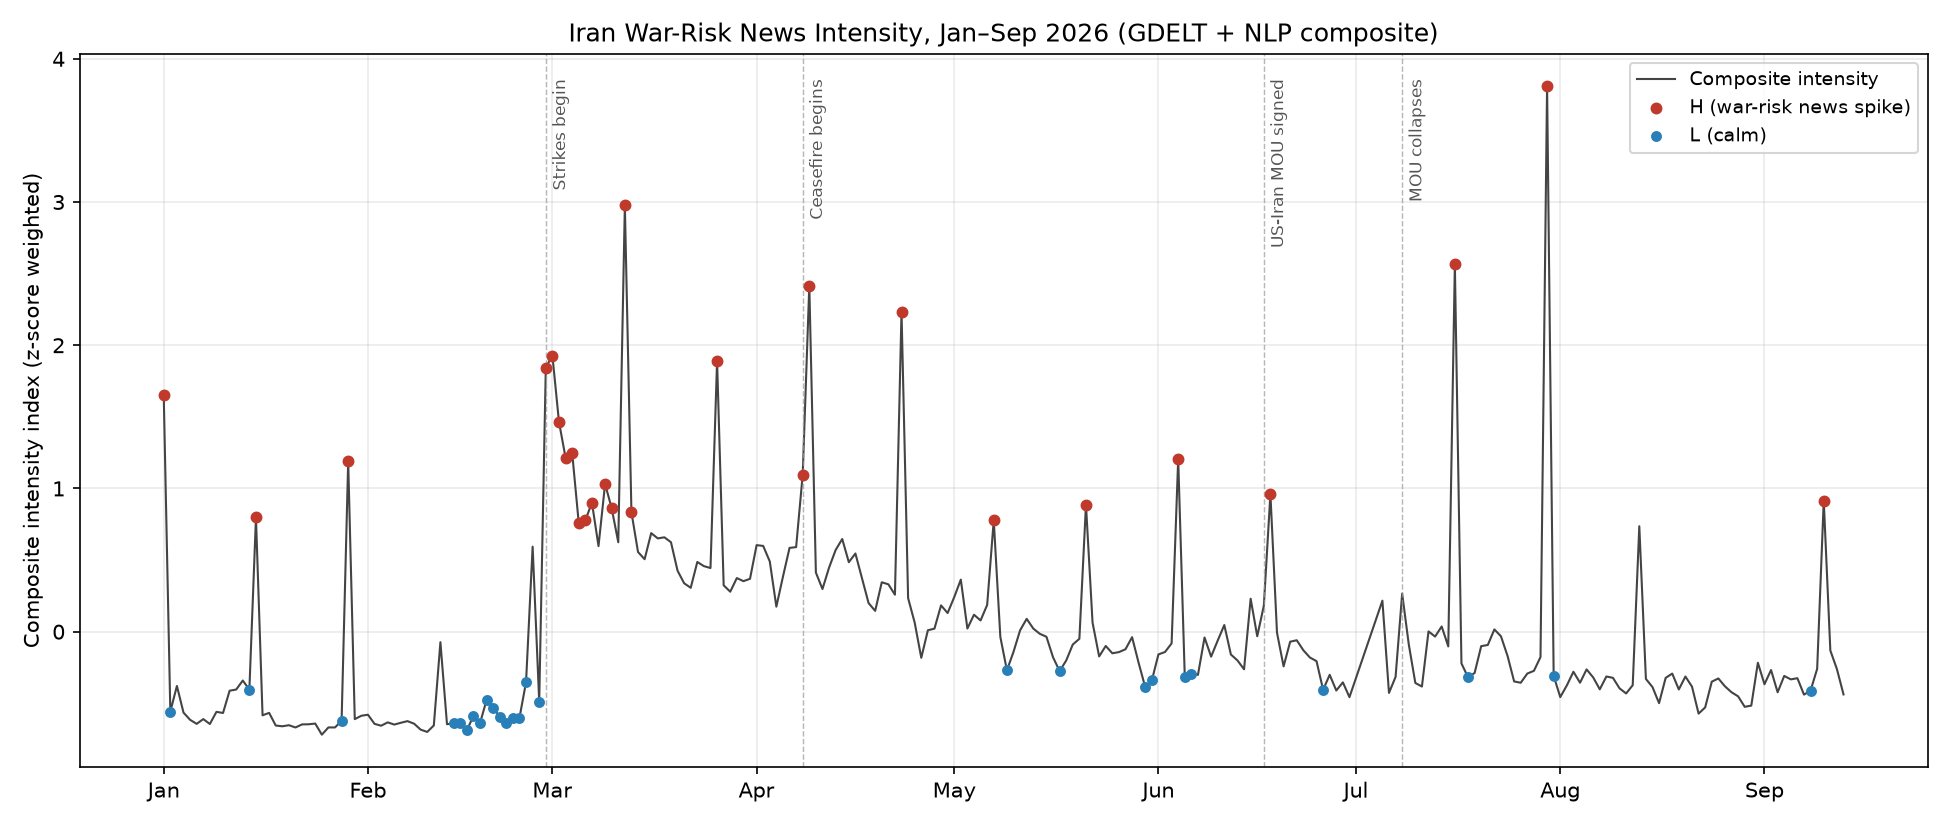

In [4]:
display(Image('figure1_intensity_timeline.png'))

### A possible explanation for some visible counterintuitive results

The intensity index spikes sharply on 2026-04-08/04-09, right after the ceasefire begins, instead of falling. Two things going on here. First, the index measures news-driven variance and attention, not direction, a sudden ceasefire announcement is itself a big, uncertain, breaking-news event, so GDELT's volume signal spikes on it just like it would on a sudden attack. Second, the coverage those two days was not actually calm, headlines include "Iran closes Hormuz Strait in response to Israeli attacks on Lebanon," "At least 182 killed as Israel strikes central Beirut," and "Shaky ceasefire unlikely to stop cyberattacks from Iran-linked hackers." The US-Iran ceasefire held, but the conflict's theatre widened to Israel/Lebanon and Hormuz at the same time, and most coverage was framed as fragile rather than resolved, which the lexicon, tone, and FinBERT components all pick up as escalation-coded language.

This actually fits the identification strategy rather than breaking it. Rigobon & Sack only need elevated variance on H-days, not a particular sign of news, so a high-uncertainty, ceasefire-with-collapse-risk day is a fair H-day even though it looks odd at first glance.

## 3. Table 1: H/L regime dates

In [5]:
table1 = pd.read_csv(DATA_PROCESSED / 'table1_regime_dates.csv')
table1

,date,composite_intensity,direction,is_H,is_L,confound_flag
0,2026-01-01,1.650328,Unclear,True,False,False
1,2026-01-02,-0.557390,Increased,False,True,False
2,2026-01-14,-0.404279,Increased,False,True,False
3,2026-01-15,0.797388,Decreased,True,False,False
4,2026-01-28,-0.621914,Decreased,False,True,True
5,2026-01-29,1.188778,Unclear,True,False,False
6,2026-02-14,-0.640586,Increased,False,True,False
7,2026-02-15,-0.637910,Decreased,False,True,False
8,2026-02-16,-0.689502,Decreased,False,True,False
9,2026-02-17,-0.589880,Increased,False,True,False


Regime is H (top decile intensity, a war-news day) or L (a matched calm day picked close to an H-day, following the same logic as the original paper). Confound flag marks a day that also happens to be an FOMC date, we keep it in the sample and just flag it rather than dropping it, so it can be checked instead of hidden.

## 4. Results by normalizing variable

For every other variable $x_j$ we get three estimates of the same war-risk sensitivity coefficient $d$, all from the same $\Omega_H$ and $\Omega_L$ matrices:

$$\hat{d}=\Delta\Omega_{22}/\Delta\Omega_{21}\ \ (Eq.6) \qquad \hat{d}=\Delta\Omega_{21}/\Delta\Omega_{11}\ \ (Eq.7)$$

plus the IV versions ($\omega_1$, $\omega_2$, $\omega_3$, the last one is the two-instrument overidentified specification with a Sargan/J test). If the model actually fits a given variable, all of these should land close to each other, if they don't, that's a warning sign (see the dedicated Eq(10) section further down).


In [6]:
results = {}
for nv in NORMALIZING_VARIABLES_TO_RUN:
    results[nv] = {
        'table2': pd.read_parquet(DATA_PROCESSED / f'table2_estimates_{nv}.parquet'),
        'table3': pd.read_parquet(DATA_PROCESSED / f'table3_variance_decomp_{nv}.parquet'),
    }
print(f"Primary normalizing variable: {NORMALIZING_VARIABLES_TO_RUN[0]}")
results[NORMALIZING_VARIABLES_TO_RUN[0]]['table2']

Primary normalizing variable: treasury_2y


,variable,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat,iv_w1_pvalue,iv_w2_coef,iv_w2_tstat,iv_w2_pvalue,iv_w3_coef,iv_w3_tstat,iv_w3_pvalue,iv_w3_sargan_stat,iv_w3_sargan_pvalue,bootstrap_mean,bootstrap_se,bootstrap_ci_low,bootstrap_ci_high,n_obs
0,brent_oil,250.598801,214.889862,91.940143,1.254231,0.209758,239.513542,2.017648,0.043628,176.956132,1.885663,0.059340,2.130660,0.144379,81.563564,1143.638394,-1485.383120,937.135050,37
1,wti_oil,309.735627,224.732953,95.762449,1.162628,0.244980,309.387708,1.932563,0.053290,201.737237,1.682269,0.092517,2.652154,0.103410,79.312462,1161.016517,-1693.307983,958.850192,37
2,gold,-855.786279,-641.166776,-1260.070610,-1.554915,0.119966,-2731.759519,-0.459510,0.645868,-1228.213807,-1.436873,0.150754,0.232193,0.629903,-766.843800,8868.047793,-7417.260869,5491.502431,37
3,dollar_index,1446.716574,0.135870,1.973984,0.639998,0.522174,43.967380,0.564679,0.572292,-0.624893,-0.129380,0.897057,11.076905,0.000874,3.873897,19.899716,-30.542029,46.732200,37
4,vix,203.526081,20.730732,11.984064,0.420383,0.674206,154.945607,0.590409,0.554917,11.883823,0.416249,0.677228,5.508776,0.018921,51.512944,354.508604,-261.737065,344.879112,37
5,sp500,-995.876173,-2007.542377,-961.317191,-1.264049,0.206212,-1548.611486,-1.259505,0.207848,-1129.829809,-1.557711,0.119302,0.403152,0.525466,-2236.758189,18665.136847,-13577.882430,8536.638217,37
6,em_equity,-56.317863,-20.903381,-16.793720,-1.037293,0.299599,-54.808048,-1.343907,0.178978,-17.777998,-1.088265,0.276478,2.818133,0.093205,-33.760612,209.422700,-294.697664,155.383527,37
7,israel_equity,-137.905474,-18.306521,-10.350450,-0.437266,0.661919,-72.809443,-1.118480,0.263362,-8.580197,-0.352030,0.724816,4.703345,0.030104,-31.418449,130.659721,-287.984331,186.956866,37
8,treasury_10y,0.404174,0.371560,0.553089,2.025068,0.042860,0.715442,2.163910,0.030471,0.472468,1.850672,0.064217,0.914611,0.338894,0.651734,2.293740,-2.217311,3.857096,37
9,breakeven_10y,2.386729,0.258410,0.225547,1.241372,0.214468,1.479115,0.962648,0.335724,0.208915,1.150937,0.249758,12.606292,0.000384,0.187570,1.772151,-2.963862,2.333724,37


A few things worth looking at in this table: Eq(6) and Eq(7) only agree if the model's assumptions hold for that variable, so a big gap between them is itself informative. Look at the IV t-stats, not just the coefficients, before trusting a number. Sargan p-value below 0.05 means omega1 and omega3 disagree more than chance would explain, a soft sign the identifying assumption is shaky for that variable.

### Comparison to Rigobon & Sack (2003): Iraq 2003 vs. Iran 2026 (treasury_2y run only)

In [7]:
comp_path = DATA_PROCESSED / 'table2_comparison.html'
if comp_path.exists():
    with open(comp_path) as f:
        display(HTML(f.read()))

Variable,Iraq 2003 coef,Iraq 2003 t-stat,Iran 2026 coef,Iran 2026 t-stat,Same direction?
brent_oil,-,-,91.940,1.254,New variable (no 2003 analog)
wti_oil,0.770,2.440,95.762,1.163,Yes
gold,1.300,0.260,-1260.071,-1.555,No
dollar_index,-0.440,2.220,1.974,0.640,No
vix,-,-,11.984,0.420,New variable (no 2003 analog)
sp500,-3.760,2.900,-961.317,-1.264,Yes
em_equity,-,-,-16.794,-1.037,New variable (no 2003 analog)
israel_equity,-,-,-10.350,-0.437,New variable (no 2003 analog)
treasury_10y,-0.260,11.850,0.553,2.025,No
breakeven_10y,-0.110,3.450,0.226,1.241,No


Same direction just checks if the sign matches the 2003 Iraq result. A "No" is not automatically wrong, the two wars are different (oil shock vs. flight to safety, more on this in the Discussion), it's just flagged so it isn't missed.

In [8]:
print(f"Secondary normalizing variable: {NORMALIZING_VARIABLES_TO_RUN[1]}")
results[NORMALIZING_VARIABLES_TO_RUN[1]]['table2']

Secondary normalizing variable: brent_oil


,variable,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat,iv_w1_pvalue,iv_w2_coef,iv_w2_tstat,iv_w2_pvalue,iv_w3_coef,iv_w3_tstat,iv_w3_pvalue,iv_w3_sargan_stat,iv_w3_sargan_pvalue,bootstrap_mean,bootstrap_se,bootstrap_ci_low,bootstrap_ci_high,n_obs
0,wti_oil,1.162131,1.112264,1.111025,14.341769,0.000000e+00,1.160141,16.785071,0.000000,1.136043,15.458596,0.000000e+00,24.230798,8.545478e-07,1.085232,0.104251,0.866580,1.239456,37
1,gold,-1.001439,-10.174586,-10.806349,-3.417557,6.318583e-04,-5.510342,-0.466543,0.640827,-10.351117,-3.474028,5.127079e-04,0.722296,3.953919e-01,-11.129992,5.357546,-21.846623,-4.679593,37
2,dollar_index,0.085650,0.042617,0.041991,3.986164,6.715013e-05,0.102822,1.968610,0.048998,0.044289,4.171822,3.021743e-05,5.369291,2.049431e-02,0.044525,0.018144,0.015050,0.081214,37
3,vix,0.238020,0.329174,0.309728,3.475654,5.096100e-04,0.338184,1.242526,0.214043,0.313169,3.733154,1.890968e-04,0.055634,8.135345e-01,0.367459,0.179455,0.144292,0.736578,37
4,sp500,-3.668174,-10.121041,-9.485204,-3.260958,1.110366e-03,-7.237373,-0.854879,0.392618,-9.174641,-3.641835,2.707018e-04,0.332952,5.639259e-01,-11.346456,6.011954,-22.709249,-4.028678,37
5,em_equity,-0.108132,-0.202169,-0.192833,-3.627990,2.856365e-04,-0.192387,-0.870997,0.383756,-0.192776,-3.880831,1.041000e-04,0.000022,9.962964e-01,-0.224017,0.115754,-0.466444,-0.084957,37
6,israel_equity,-0.207265,-0.226187,-0.201536,-2.212490,2.693282e-02,-0.296482,-1.054136,0.291821,-0.210459,-2.670368,7.576813e-03,0.412977,5.204622e-01,-0.260109,0.166068,-0.641831,-0.040426,37
7,treasury_2y,0.004654,0.003990,0.004175,2.017648,4.362789e-02,0.010877,1.254231,0.209758,0.004196,2.021422,4.323610e-02,1.661418,1.974120e-01,0.004405,0.003038,-0.000368,0.011853,37
8,treasury_10y,0.000916,0.003043,0.003188,1.889129,5.887453e-02,0.006172,0.831022,0.405961,0.003139,1.872488,6.113910e-02,0.418434,5.177196e-01,0.003204,0.002410,-0.001091,0.008160,37
9,breakeven_10y,0.004364,0.002624,0.002662,3.974195,7.061784e-05,0.005154,2.450550,0.014264,0.002664,3.976145,7.004152e-05,4.302062,3.806620e-02,0.002667,0.000941,0.000948,0.004648,37


## 5. Table 3: Variance decomposition (both normalizing variables)

Following the original paper, this is a lower-bound estimate of how much of each variable's own variance is explained by the war-risk factor:

$$\%\ explained = \hat{d}^2 \cdot \Delta Var(x_1) \ / \ Var(x_j)$$

In [9]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    print(f"--- {nv} ---")
    display(results[nv]['table3'])

--- treasury_2y ---


,variable,var_L,var_H,predicted_delta_var,pct_explained_H_days,pct_explained_all_days
0,brent_oil,2.868137,32.217009,4.606880,0.142995,0.323117
1,wti_oil,2.882852,40.819104,4.997893,0.122440,0.383378
2,gold,6715.441105,7014.483547,865.338978,0.123365,0.103148
3,dollar_index,0.072606,0.179734,0.002124,0.011816,0.019324
4,vix,3.464228,5.987110,0.078272,0.013073,0.034142
5,sp500,4042.538869,5132.137542,503.651254,0.098137,0.145230
6,em_equity,1.752132,2.393724,0.153706,0.064212,0.125569
7,israel_equity,2.571684,3.947574,0.058387,0.014791,0.018595
8,treasury_10y,0.001483,0.001565,0.000167,0.106546,0.093719
9,breakeven_10y,0.000273,0.000609,0.000028,0.045522,0.062794


--- brent_oil ---


,variable,var_L,var_H,predicted_delta_var,pct_explained_H_days,pct_explained_all_days
0,wti_oil,2.882852,40.819104,36.227565,0.887515,2.778939
1,gold,6715.441105,7014.483547,3427.278280,0.488600,0.408528
2,dollar_index,0.072606,0.179734,0.051750,0.287924,0.470882
3,vix,3.464228,5.987110,2.815482,0.470257,1.228106
4,sp500,4042.538869,5132.137542,2640.491619,0.514501,0.761398
5,em_equity,1.752132,2.393724,1.091328,0.455912,0.891554
6,israel_equity,2.571684,3.947574,1.192056,0.301972,0.379654
7,treasury_2y,0.001798,0.002343,0.000512,0.218322,0.238106
8,treasury_10y,0.001483,0.001565,0.000298,0.190617,0.167669
9,breakeven_10y,0.000273,0.000609,0.000208,0.341358,0.470878


Values above 100% do show up here, that's a flag for a noisy or weak estimate for that variable, not a literal claim that war risk explains more than all the variance in it.

## 6. Robustness checks

In [10]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    print(f"--- {nv}: first-half vs second-half coefficient stability ---")
    display(pd.read_parquet(DATA_PROCESSED / f'robustness_stability_{nv}.parquet'))

--- treasury_2y: first-half vs second-half coefficient stability ---


,variable,status,coef_first_half,coef_second_half,stability_z,stability_pvalue
0,brent_oil,ok,56.619440,1170.988877,-0.035004,0.972077
1,wti_oil,ok,53.485573,1479.990754,-0.035217,0.971907
2,gold,ok,-1771.340225,17967.459422,-0.037883,0.969781
3,dollar_index,ok,3.339911,-62.742838,0.035609,0.971594
4,vix,ok,32.664739,-928.774323,0.035828,0.971419
5,sp500,ok,-1395.414196,21083.704315,-0.036339,0.971012
6,em_equity,ok,-27.667886,468.001043,-0.036046,0.971246
7,israel_equity,ok,-20.835588,381.092756,-0.034900,0.972160
8,treasury_10y,ok,0.523494,3.931034,-0.038644,0.969174
9,breakeven_10y,ok,0.142124,2.448276,-0.036537,0.970854


--- brent_oil: first-half vs second-half coefficient stability ---


,variable,status,coef_first_half,coef_second_half,stability_z,stability_pvalue
0,wti_oil,ok,1.120646,0.960202,0.978369,0.327892
1,gold,ok,-10.450806,-30.366262,0.424363,0.671301
2,dollar_index,ok,0.034774,0.209122,-0.522063,0.601627
3,vix,ok,0.274250,1.117474,-0.472065,0.636880
4,sp500,ok,-8.161640,-39.390382,0.473973,0.635519
5,em_equity,ok,-0.162467,-0.942564,0.502944,0.615004
6,israel_equity,ok,-0.155539,-1.389190,0.564337,0.572525
7,treasury_2y,ok,0.003006,0.035192,-0.783155,0.433536
8,treasury_10y,ok,0.002446,0.025957,-0.955702,0.339223
9,breakeven_10y,ok,0.002337,0.009426,-0.742233,0.457946


In [11]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    sens = pd.read_parquet(DATA_PROCESSED / f'robustness_threshold_sensitivity_{nv}.parquet')
    print(f"--- {nv}: H/L threshold sensitivity ---")
    if not sens.empty:
        display(sens.pivot(index='variable', columns='H_quantile', values='coef'))

--- treasury_2y: H/L threshold sensitivity ---


H_quantile,0.85,0.90,0.95
variable,,,
bbb_spread,0.115971,0.719659,2.773585
breakeven_10y,0.192046,0.302815,0.018868
brent_oil,77.197855,213.606647,503.386638
broad_dollar,0.932632,5.021923,2.359245
dollar_index,2.831651,7.664730,5.405697
em_equity,-14.712217,-29.885529,-44.895428
gold,-470.677730,-1054.748595,-3675.380030
hy_spread,0.544343,2.499797,8.124796
israel_equity,-4.478743,-1.596676,16.119226


--- brent_oil: H/L threshold sensitivity ---


H_quantile,0.85,0.90,0.95
variable,,,
bbb_spread,0.001758,0.001911,0.004688
breakeven_10y,0.002902,0.003034,0.002360
broad_dollar,0.062043,0.067735,0.100772
dollar_index,0.042801,0.052306,0.097410
em_equity,-0.174313,-0.224754,-0.417284
gold,-5.359224,-4.933985,-23.740134
hy_spread,0.010525,0.009972,0.014252
israel_equity,-0.179319,-0.266438,-0.577372
sp500,-8.300068,-10.240912,-19.216119


Stability splits the war into two halves and re-estimates in each, a coefficient that jumps around a lot between halves shouldn't be trusted much (the war's phases were pretty different, initial strikes vs. later ceasefire-and-collapse). Threshold sensitivity redoes the whole H/L split at three different cutoffs, small movement means the result doesn't depend on us picking exactly the top decile as H.

## 7. Eq(10): does the paper's own equivalence actually hold here?

The paper (Rigobon & Sack 2003, p.6) writes the $\omega_1$ IV estimator as a closed form and says it's identical to Eq(7):

$$\hat{d}=\frac{Cov_H(\Delta x_1,\Delta x_2)-Cov_L(\Delta x_1,\Delta x_2)}{Var_H(\Delta x_1)-Var_L(\Delta x_1)}\ \ (Eq.10)$$

That equivalence is only exact if $\Delta x$ has zero mean (the paper says this outright in its own footnote 2), which real market data won't do exactly. Eq(7) here is a plain covariance ratio (de-means within each regime), the IV version (`iv_w1_coef` in Table 2) is a real pooled 2SLS regression with an intercept, so the two can drift apart whenever the H-day and L-day means of the normalizing variable aren't close relative to its own spread.

In [12]:
panel = pd.read_parquet(DATA_PROCESSED / 'master_panel_filtered.parquet')
rows = []
for nv in NORMALIZING_VARIABLES_TO_RUN:
    h = panel.loc[panel['is_H'], f'd_{nv}'].dropna()
    l = panel.loc[panel['is_L'], f'd_{nv}'].dropna()
    rows.append({'normalizing_variable': nv, 'mean_d_on_H': h.mean(), 'mean_d_on_L': l.mean(),
                 'std_d_all_days': panel[f'd_{nv}'].std()})
pd.DataFrame(rows)

,normalizing_variable,mean_d_on_H,mean_d_on_L,std_d_all_days
0,treasury_2y,0.026667,0.01125,0.046353
1,brent_oil,0.677619,0.68500,3.775926


2-year Treasury yield changes are tiny to begin with, so even a small difference between its H-day and L-day mean is large relative to its own variance, and Eq(7) vs. the IV omega1 estimate pull apart a lot for several variables below. Brent crude's day-to-day moves are much bigger, so the same kind of mean difference barely matters and the two estimates stay close, which is what the paper's own algebra predicts when its assumptions are closer to holding.

In [13]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    t2 = results[nv]['table2'][['variable', 'eq7_direct', 'iv_w1_coef']].copy()
    t2['ratio_iv_over_eq7'] = t2['iv_w1_coef'] / t2['eq7_direct']
    print(f'--- {nv}: Eq(7) vs. IV omega1 ---')
    display(t2)

--- treasury_2y: Eq(7) vs. IV omega1 ---


,variable,eq7_direct,iv_w1_coef,ratio_iv_over_eq7
0,brent_oil,214.889862,91.940143,0.427848
1,wti_oil,224.732953,95.762449,0.426117
2,gold,-641.166776,-1260.070610,1.965277
3,dollar_index,0.135870,1.973984,14.528523
4,vix,20.730732,11.984064,0.578082
5,sp500,-2007.542377,-961.317191,0.478853
6,em_equity,-20.903381,-16.793720,0.803397
7,israel_equity,-18.306521,-10.350450,0.565397
8,treasury_10y,0.371560,0.553089,1.488560
9,breakeven_10y,0.258410,0.225547,0.872827


--- brent_oil: Eq(7) vs. IV omega1 ---


,variable,eq7_direct,iv_w1_coef,ratio_iv_over_eq7
0,wti_oil,1.112264,1.111025,0.998886
1,gold,-10.174586,-10.806349,1.062092
2,dollar_index,0.042617,0.041991,0.985315
3,vix,0.329174,0.309728,0.940925
4,sp500,-10.121041,-9.485204,0.937177
5,em_equity,-0.202169,-0.192833,0.953820
6,israel_equity,-0.226187,-0.201536,0.891016
7,treasury_2y,0.003990,0.004175,1.046282
8,treasury_10y,0.003043,0.003188,1.047588
9,breakeven_10y,0.002624,0.002662,1.014252


`ratio_iv_over_eq7` close to 1.0 is good, it means the IV route and the closed-form route agree the way the paper says they should. For `treasury_2y` a few variables (dollar_index, broad_dollar, vix) have ratios wildly away from 1.0, on top of the weak-identification evidence Figure 2 already shows. For `brent_oil` almost every ratio sits reasonably close to 1.0, gold is the one exception, which lines up with gold being the odd result flagged in the Discussion.

## 8. Figure 3: raw variance and covariance on war-news vs. calm days

Everything above comes out of $\Omega_H$ and $\Omega_L$, the covariance matrices of daily changes computed separately on H-days and L-days:

$$\Omega \equiv E\left([\Delta x_1\ \Delta x_2]'\,[\Delta x_1\ \Delta x_2]\right)$$

This figure just plots those raw numbers directly instead of a ratio or a t-stat, so we can see what's actually feeding the estimator.

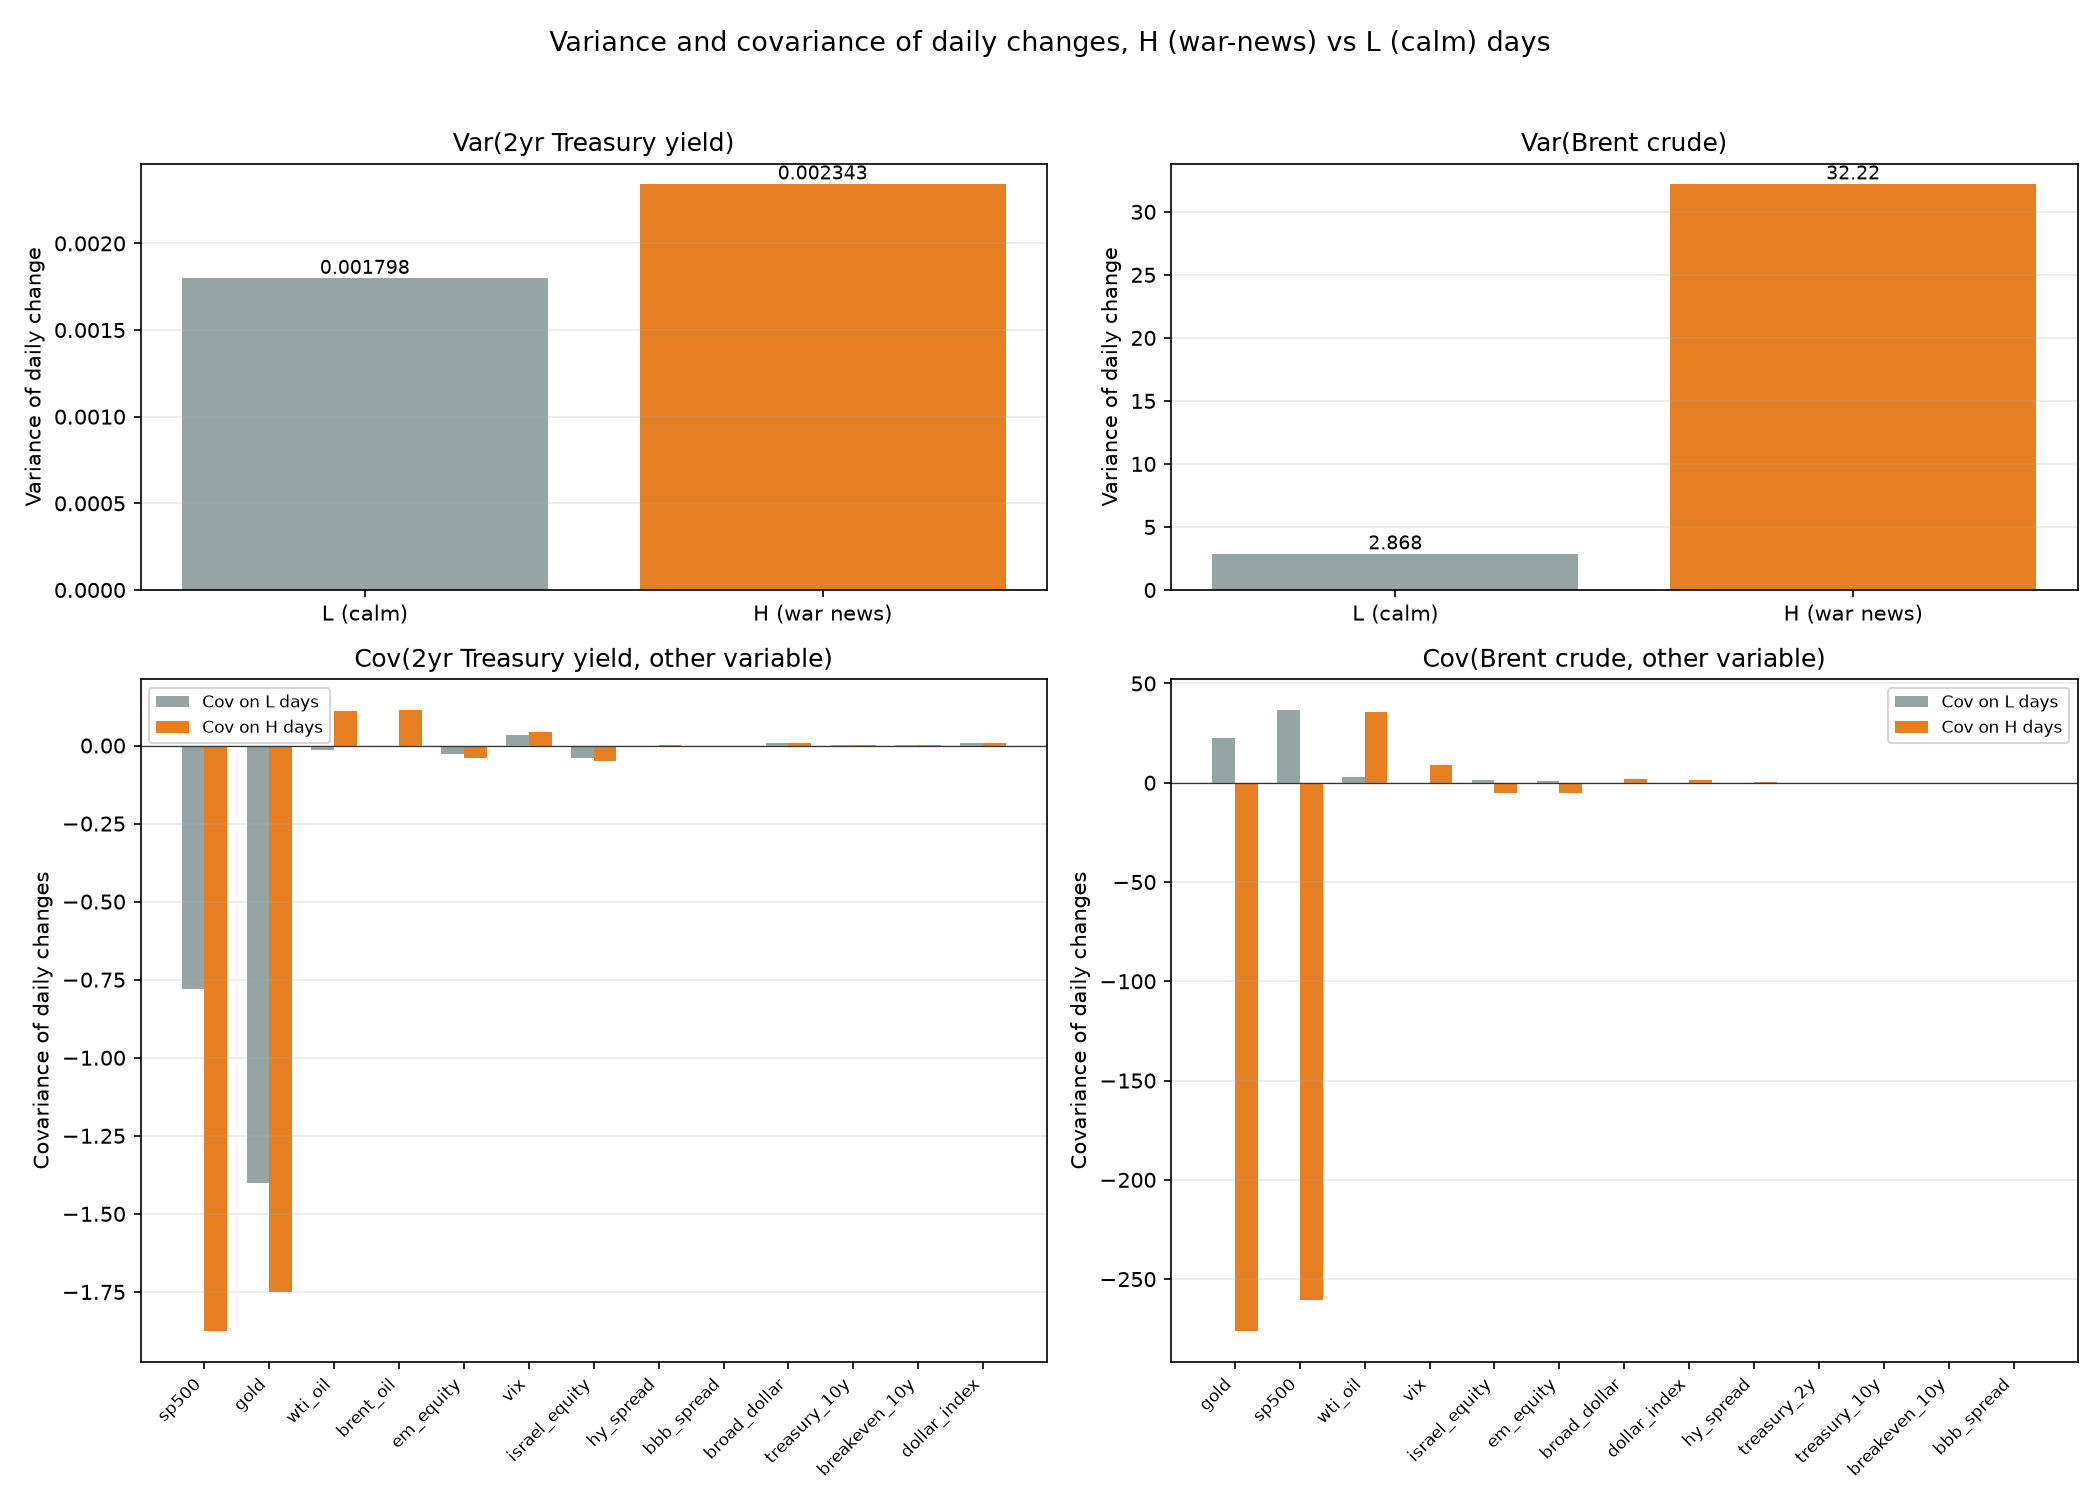

In [14]:
display(Image('figure3_var_covar.png'))

Top row: the normalizing variable's own variance on L-days vs. H-days, Brent oil's jumps about 11x on war-news days, the Treasury yield's barely moves, same identification gap Figure 2 shows, here in raw units. Bottom row: covariance with every other variable, H-days vs. L-days, S&P 500 and gold dominate the y-axis in both panels purely because they're large, unstandardized numbers, not because they're the most "explained" variables (Table 2/3's ratios already correct for that scale difference).

## 9. Figure 2: why Brent oil identifies the model better than the 2yr Treasury yield

(a) the identification condition itself, a normalizing variable's own variance should jump on war-news days; (b) |t-statistics| for every other variable's sensitivity under each normalizing-variable choice; (c) a scale-free instability score (swing across three alternative H-day thresholds) computed for every variable, not just one example.

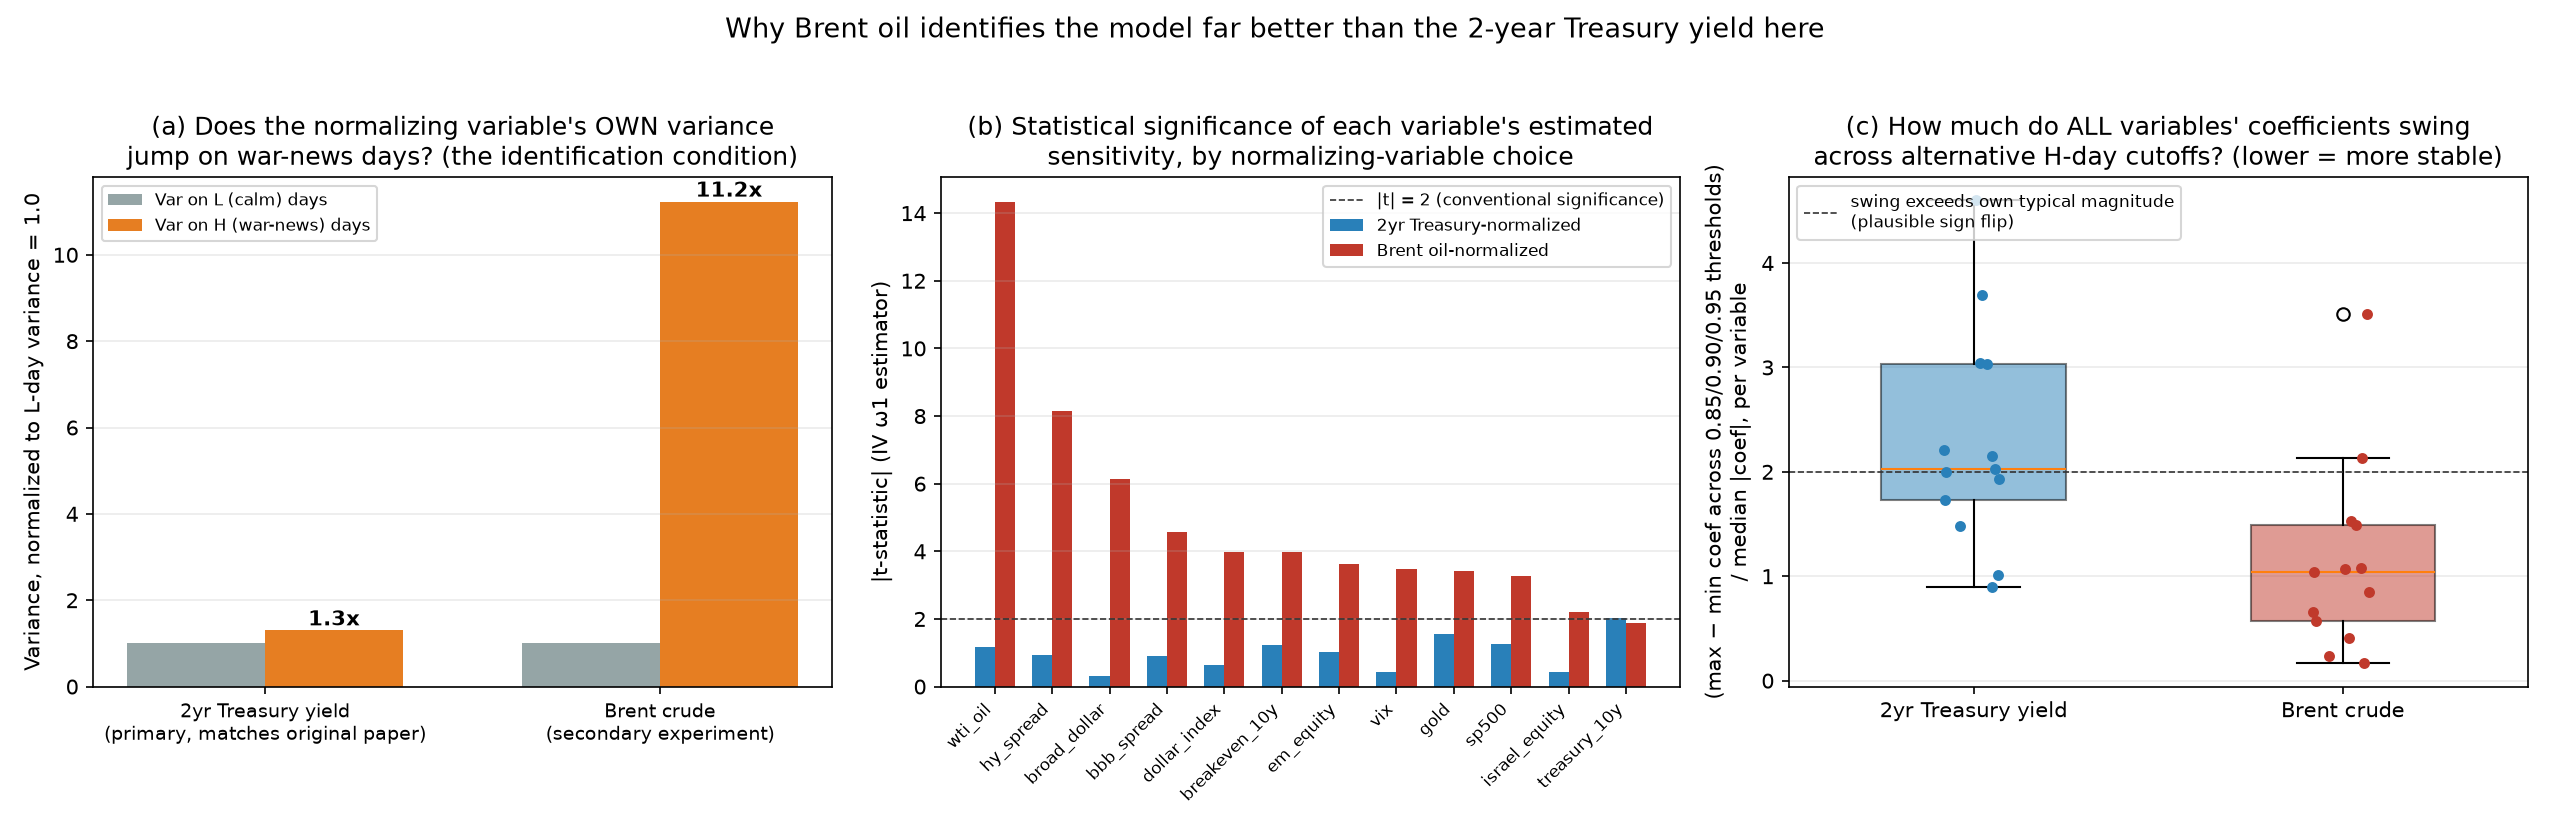

In [15]:
display(Image('figure2_oil_vs_treasury.png'))

Read panel (a) first, it's the actual precondition for everything else. If the normalizing variable's own variance doesn't jump on H-days, none of the downstream coefficients for that choice can be trusted much.

## 10. The assumption on "non-war" effects, and what our results say about it

The whole method rests on one assumption (Rigobon & Sack 2003, p.5): only the variance of the war-risk factor $z_1$ changes between H-days and L-days. Everything else (monetary policy news, other macro data, unrelated shocks) is assumed to keep the same variance in both sets of days, that's what lets us blame the entire change in $\Omega$ on war risk alone:

$$\Delta\Omega_{11}=\Delta\sigma^2(z_1) \qquad \Delta\Omega_{21}=\hat{d}\cdot\Delta\sigma^2(z_1) \qquad \Delta\Omega_{22}=\hat{d}^2\cdot\Delta\sigma^2(z_1)$$

We can't verify this directly since $z_1$ is unobserved by design, but we can look for cracks in it.

In [16]:
n_h, n_l = int(panel['is_H'].sum()), int(panel['is_L'].sum())
n_confound_h = int((panel['is_H'] & panel['confound_flag']).sum())
n_confound_l = int((panel['is_L'] & panel['confound_flag']).sum())
sargan_counts = {nv: int((results[nv]['table2']['iv_w3_sargan_pvalue'] < 0.05).sum()) for nv in NORMALIZING_VARIABLES_TO_RUN}
print(f"H-days: {n_h} (confound-flagged: {n_confound_h}), L-days: {n_l} (confound-flagged: {n_confound_l})")
print('Sargan rejections at 5%:', sargan_counts)

H-days: 24 (confound-flagged: 0), L-days: 21 (confound-flagged: 1)
Sargan rejections at 5%: {'treasury_2y': 5, 'brent_oil': 4}


Of 24 H-days, 0 land on a known FOMC date, of 21 L-days, 1 does. So the obvious, known confound (Fed meetings) is basically not contaminating the H set, which is good, but this only covers confounds we thought to list in advance. The Eq(6) vs. Eq(7) disagreement from section 7 is really a live test of the same assumption, if some other factor's variance also moved on our H-days, $\Delta\Omega$ stops having the clean shape the assumption predicts. Same story with the Sargan rejections above, more rejections means more variables where omega1 and omega2 aren't telling a consistent story.

**What this predicts, put simply:** treasury_2y is more likely picking up a mix of war risk and other macro noise (rate expectations, Fed-adjacent moves not on our confound calendar), since the 2-year yield reacts to a lot more than just war risk day to day. Brent oil is a more direct, single-channel bet (Hormuz disruption to physical oil supply), so there are fewer other big factors competing to move its variance on the same days, and the assumption ends up closer to true for it. Same conclusion Figure 2 already points to, from a completely different angle.

## 11. Discussion

**Data.** 4,500 GDELT-indexed articles across 18 of 19 biweekly windows (Jan 1 to Sep 17, 2026), one window (Aug 27 to Sep 9) couldn't be fetched after repeated GDELT rate-limiting and is documented as a gap rather than silently dropped. The NLP relevance filter (lexicon) was evaluated against a 176-article reference set (labeled by Claude reading each headline, disclosed in `AI_USE.md`), precision 0.83, recall 0.29, picky but accurate, missing many genuinely relevant articles (diplomatic talks, oil-market commentary) that don't use its specific escalation vocabulary. The three article-level NLP scores agree reasonably well with each other (TF-IDF tone and FinBERT correlate at 0.885, both correlate more loosely, 0.57 to 0.66, with the pure-keyword lexicon), which is the expected pattern for methods using genuinely different mechanisms.

**Two normalizing-variable specifications tell different stories.** The primary specification (2-year Treasury yield, matching Rigobon & Sack 2003 exactly) is *weakly identified*, the yield's own variance is not clearly elevated on H-days in this sample, unlike Iraq 2003 where it was roughly 6x higher on war-news days. Figure 2 makes this concrete, the yield's own H/L variance ratio is only 1.3x (vs. oil's 11.2x), which shows up as low |t-statistics| across nearly every other variable and as coefficient swings across alternative H-day thresholds that approach or exceed the "plausible sign flip" boundary. The secondary specification (Brent crude, motivated by the war's Strait-of-Hormuz/oil-supply character) is stable and statistically strong across nearly every variable, most |t-statistics| exceed 2, several exceed 6 to 8, and threshold-sensitivity swings are smaller and more consistently one-sided across the whole variable set (Figure 2c), not just a single example.

**Economic interpretation.** Against the oil anchor, equities fall (S&P 500, Israel, EM), volatility and the dollar rise, credit spreads widen, all consistent with a classic risk-off shock. But Treasury yields and inflation breakevens *rise*, not fall, with war-risk-driven oil moves. That's the opposite mechanism from Iraq 2003, where war risk operated as a flight-to-safety shock (yields fell as investors sought duration and the outlook darkened). The 2026 Iran war instead looks like it transmits mainly as an **oil supply shock**, inflationary and hawkish for policy rates, which lines up with the war's actual character (a Strait of Hormuz disruption to global energy supply, per the timeline in Table 1) far better than a generic "fear of war" story does. This is also why Brent oil, not the 2-year Treasury yield, is the variable whose own variance is genuinely elevated on war-news days in this episode, the shock originates in the oil market and propagates outward, rather than originating in a generalized flight to safety that would show up first in Treasuries.

**A genuinely counterintuitive, robust result: gold falls.** Gold's coefficient is negative and consistently signed across both the partial-data preliminary run and this final full-corpus run (about -10 to -11 per $1 Brent move, t around -3.4). A classic safe-haven story would predict gold *rising* alongside oil on war risk. One plausible reading, the broad dollar index rises strongly and significantly alongside oil in this episode (t=6.1), and dollar strength mechanically pressures dollar-denominated gold prices even when "fear" demand for gold might otherwise be rising, a currency effect dominating a safe-haven effect. Flagged as an open question rather than resolved, in line with the original paper's own restraint about not overclaiming mechanism from a reduced-form coefficient.

**Robustness.** The first-half/second-half stability check does not reject coefficient stability for the Brent-oil specification (small samples per half limit power, so this is weak evidence of stability rather than strong evidence). The Sargan/J overidentification test rejects for a handful of variables (notably `wti_oil`, which is almost mechanically collinear with `brent_oil`, an expected instrument-strength artifact rather than a substantive concern) but not for the majority of variables, including the headline equity/credit/inflation results. H/L threshold sensitivity (0.85/0.90/0.95 quantile cutoffs) shows the sign and rough order of magnitude are preserved for most Brent-oil-normalized coefficients, though point estimates aren't perfectly stable with only 20-something H-days to work with.

**Limitations** (see `report/report.pdf` for the full list, including a data-driven look at the identifying assumption itself): the confound calendar (FOMC dates) flags but does not exclude potentially contaminated days; each of the three NLP scoring methods has its own blind spots (the lexicon needs the literal word "iran" and misses relevant articles that don't use it, e.g. a Beirut-strikes headline scoring intensity 4.0 gets excluded entirely); z-scoring the five composite components fixes their mean and variance but not their shape, so a zero-inflated NLP component can occasionally swing the composite by more than its assigned weight; the on-the-run Treasury liquidity premium from the original 9-variable set is deferred to Phase B; trading-calendar alignment across US/Gulf/Israeli market hours is an approximation; t-stats aren't corrected for multiple comparisons across 13 variables x 3 estimators x 2 normalizing specifications; and one 2-week news window is missing from the corpus due to GDELT rate-limiting.

## 12. Where this analysis could be improved

- **Learn the relevance filter instead of hand-coding it.** Recall is only 0.29 because the lexicon needs the literal word "iran" plus a fixed term list (it misses "182 killed as Israel strikes central Beirut" entirely). We already have 176 Claude-judged labels sitting there, even a simple classifier (logistic regression on TF-IDF features) trained on those would likely beat the hand-built keyword rule.
- **Get a second, independent labeler for the eval set.** Right now relevance judgments are single-pass, from one LLM reading each headline once. A second human or model pass with an inter-annotator agreement score (Cohen's kappa) would tell us how much to trust precision/recall = 0.83/0.29 in the first place.
- **Full VAR pre-whitening instead of per-variable AR(1).** The original paper filters serial correlation with a VAR across all variables together, here we only remove each variable's own lag-1 autocorrelation. A full VAR would also catch cross-variable lead-lag effects (oil today predicting equities tomorrow), which the current AR(1) step can't see.
- **Robust scaling for the zero-inflated NLP components.** Lexicon, tone, and FinBERT are zero on about 93% of days then spike hard on the rest. A rank-based or median/IQR standardization would probably be less sensitive to those spikes than a mean/std z-score.
- **Test more than 2 normalizing variables, and pick with a rule, not by hand.** We ran treasury_2y (for comparability to 2003) and brent_oil (on a theory-driven hunch). A cleaner approach: compute the Var_H/Var_L ratio for every candidate variable up front and pick whichever clears some threshold, before looking at any downstream coefficients.
- **A placebo test on the H/L split itself.** Randomly relabel H/L many times (keeping the same counts) and see how often Eq(6)/Eq(7) agree, or Sargan rejects, by pure chance. That would turn today's "these numbers seem more stable for oil than for treasury" into an actual p-value.
- **Add the GSW liquidity premium (Phase B).** Already scoped in `liquidity_premium_gsw.py` but not run, this would bring the variable set fully in line with the original paper's 9 variables plus our 5 new ones.